In [1]:
import pandas as pd
import numpy as np

# Load original merged data (for labels and base features)
df = pd.read_csv('../outputs/merged_data.csv')

# Load module outputs
nlp_features = pd.read_csv('../outputs/nlp_features.csv')
graph_features = pd.read_csv('../outputs/graph_features.csv')

# Merge everything on TransactionID
df_fusion = df[['TransactionID', 'isFraud']].copy()
df_fusion = df_fusion.merge(nlp_features, on='TransactionID', how='left')
df_fusion = df_fusion.merge(graph_features, on='TransactionID', how='left')

print("Fusion dataframe shape:", df_fusion.shape)
print("\nColumns:", df_fusion.columns.tolist())

Fusion dataframe shape: (590540, 13)

Columns: ['TransactionID', 'isFraud', 'P_email_fraud_rate', 'P_email_type_fraud_rate', 'email_domain_mismatch', 'device_fraud_rate', 'P_email_type_encoded', 'device_family_encoded', 'degree_centrality', 'node_degree', 'addr_shared_cards', 'email_shared_cards', 'card2_shared_cards']


In [4]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Load saved XGBoost model
xgb_model = joblib.load('../outputs/xgb_fraud_model.pkl')

# Rebuild the tabular feature matrix exactly as in notebook 02
nlp_cols = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo']
drop_cols = ['TransactionID', 'isFraud'] + nlp_cols

X_full = df.drop(columns=drop_cols)

# Re-encode categoricals
cat_cols = X_full.select_dtypes(include='str').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    X_full[col] = X_full[col].fillna('missing')
    X_full[col] = le.fit_transform(X_full[col])

# Get fraud probabilities from tabular model
df_fusion['xgb_fraud_proba'] = xgb_model.predict_proba(X_full)[:, 1]

print("XGBoost probabilities added")
print("Fusion shape:", df_fusion.shape)
print("\nSample xgb_fraud_proba:")
print(df_fusion['xgb_fraud_proba'].describe())

XGBoost probabilities added
Fusion shape: (590540, 14)

Sample xgb_fraud_proba:
count    590540.000000
mean          0.233492
std           0.211076
min           0.000276
25%           0.086389
50%           0.162418
75%           0.299831
max           0.999709
Name: xgb_fraud_proba, dtype: float64


In [5]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Features and target
feature_cols = [c for c in df_fusion.columns if c not in ['TransactionID', 'isFraud']]
X = df_fusion[feature_cols]
y = df_fusion['isFraud']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train fusion model
scale = (y_train == 0).sum() / (y_train == 1).sum()

fusion_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

fusion_model.fit(X_train, y_train)

y_pred = fusion_model.predict(X_test)
y_pred_proba = fusion_model.predict_proba(X_test)[:, 1]

print("Fusion Model ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fusion Model ROC-AUC: 0.9375

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.95    113975
           1       0.24      0.82      0.37      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.86      0.66    118108
weighted avg       0.97      0.90      0.93    118108


Confusion Matrix:
[[103024  10951]
 [   734   3399]]


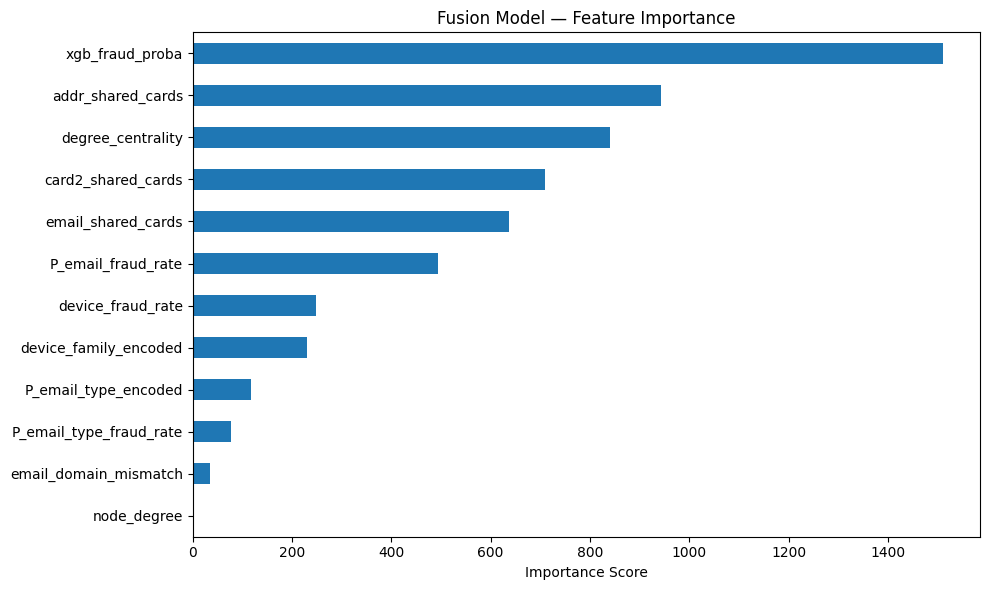

xgb_fraud_proba            1510
addr_shared_cards           943
degree_centrality           840
card2_shared_cards          709
email_shared_cards          637
P_email_fraud_rate          494
device_fraud_rate           248
device_family_encoded       231
P_email_type_encoded        118
P_email_type_fraud_rate      78
email_domain_mismatch        34
node_degree                   0
dtype: int32


In [6]:
import matplotlib.pyplot as plt

importance = pd.Series(fusion_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Fusion Model — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/fusion_importance.png', dpi=150)
plt.show()
print(importance)

## Fusion Model Results

Combined all three modules into a single LightGBM meta-model:
- **12 input features** — 1 tabular probability score + 6 NLP features + 5 graph features
- **ROC-AUC: 0.9375** — improvement over standalone XGBoost (0.933)
- **Fraud recall: 0.82** — catching 82% of actual fraud cases

**Feature importance ranking:**
1. XGBoost fraud probability (tabular module) — strongest single signal
2. addr_shared_cards (graph) — address reuse across cards reveals fraud rings
3. degree_centrality (graph) — network connectivity of card nodes
4. card2_shared_cards (graph) — card2 diversification pattern
5. email_shared_cards (graph) — email domain sharing across cards
6. P_email_fraud_rate (NLP) — domain-level fraud encoding

**Key finding:** 4 of the top 6 features come from graph and NLP modules — 
tabular features alone are insufficient. Multimodal signal fusion is essential 
for robust fraud detection.

In [7]:
joblib.dump(fusion_model, '../outputs/fusion_model.pkl')
print("Fusion model saved")

Fusion model saved
